# BARAM 2026 — 보강 EDA: 리드타임 · 분포이동 · 무발전 하한 · 풍향 교란

`EDA_MAIN.ipynb`와 `CORE_FEATURE_EDA.ipynb`가 다루지 않은 4가지 질문을 검증합니다.

1. **리드타임/시각별 오차 구조** — 예보 리드타임(16~39h)에 따라 예측이 어려워지는가?
2. **연도 간 분포 이동** — 2022/2023/2024 학습 분포가 2025 테스트와 얼마나 다른가? (RevIN·검증 대표성 판단)
3. **"바람 있는데 발전 0" 오차 하한** — NWP는 바람을 예보하지만 실제 발전이 0인 시간의 비중과 원리적 오차 하한.
4. **풍향 효과의 교란** — SW 방향 이용률 48%는 방향 효과인가, 아니면 풍속 교란인가?

> 규율: 축/제목은 영어, 설명은 한글. 검증은 시간순(2022~2023 학습 / 2024 검증). 대회 지표에 맞춰 **유효구간(실측 ≥ 설비용량 10%)** 에서 NMAE를 계산합니다.

> 데이터 제약(중요):
> - preprocessed에는 `data_available_kst_dtm`가 없어 **리드타임은 예보 규칙으로 재구성**합니다(09 KST 발효 → 다음날 01:00~24:00 = 리드 16~39h). 이 때문에 리드타임은 **하루 시각과 완전히 결합**되어 있어, 순수 리드타임 효과와 일중(diurnal) 효과는 이 데이터만으로 완전 분리되지 않습니다. 이 한계를 명시하고 해석합니다.
> - 원본 SCADA(터빈 10분 데이터)는 repo에 포함되어 있지 않으므로(gitignore), 3번 분석은 **NWP 풍속 vs KPX 발전량 프록시**로 수행합니다. 이는 테스트에서 재현 불가한 SCADA 신호를 쓰지 않는, 누설 없는 available-data 버전입니다.


## 0. 설정 & 로드

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from scipy.stats import ks_2samp
from sklearn.isotonic import IsotonicRegression

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

# preprocessed 경로 자동탐색 (환경 이식성).
CANDIDATES = [Path("preprocessed"),
              Path(__file__).parent / "preprocessed" if "__file__" in dir() else Path("preprocessed")]
DATA = next((p for p in CANDIDATES if p.exists()), Path("preprocessed"))
assert DATA.exists(), f"preprocessed dir not found; tried {CANDIDATES}"
print("DATA =", DATA.resolve())

CAP = {1: 21600, 2: 21600, 3: 21000}   # 그룹별 시간당 설비용량 (kWh)
TRAIN_YEARS = (2022, 2023, 2024)       # 연도 집계는 calendar-year 기준 2022~2024만 사용
VALID_START = pd.Timestamp("2024-01-01")
VALID_END = pd.Timestamp("2025-01-01 01:00:00")  # 2024-12-31 24:00 endpoint 포함
VALID_CF = 0.10                        # 대회 유효구간: 실측 >= 설비용량 10%

def load_train(g):
    df = pd.read_parquet(DATA / f"train_kpx_group_{g}.parquet")
    tgt = f"kpx_group_{g}"
    df["kst_dtm"] = pd.to_datetime(df["kst_dtm"])
    df[tgt] = pd.to_numeric(df[tgt], errors="coerce")   # group3 문자열 저장 대응
    df = df.dropna(subset=[tgt]).sort_values("kst_dtm").reset_index(drop=True)
    return df, tgt

def load_test(g):
    df = pd.read_parquet(DATA / f"test_kpx_group_{g}.parquet")
    df["kst_dtm"] = pd.to_datetime(df["kst_dtm"])
    return df.sort_values("kst_dtm").reset_index(drop=True)

TR = {g: load_train(g) for g in (1, 2, 3)}
TE = {g: load_test(g) for g in (1, 2, 3)}
print("train:", {g: TR[g][0].shape for g in TR})
print("test :", {g: TE[g].shape for g in TE})

DATA = preprocessed
train: {1: (26200, 72), 2: (26201, 72), 3: (17538, 72)}
test : {1: (8760, 72), 2: (8760, 72), 3: (8760, 72)}


### 공통 헬퍼 — 대회 지표(유효구간 NMAE)와 feature 목록

`CONSTRAINTS_주의점.md` §7: **NMAE = MAE / 설비용량**, 채점은 **실측 ≥ 설비용량 10%** 구간만. 예측은 [0, 용량] 클리핑.
`EDA_MAIN`의 core 40개(wind_uv) 대신, 여기서는 판단을 단순화하려 **모든 수치 feature**를 쓰되 지표만 대회 규칙에 맞춥니다.

In [2]:
def feature_cols(df, tgt):
    drop = {"kst_dtm", "forecast_id", tgt}
    return [c for c in df.columns if c not in drop]

def nmae_valid(y_true, y_pred, cap, mask_by_true=True):
    """대회 지표: 유효구간(실측>=10%)에서 MAE/설비용량. mask_by_true=False면 전체구간."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    y_pred = np.clip(y_pred, 0, cap)
    if mask_by_true:
        m = y_true >= VALID_CF * cap
    else:
        m = np.ones_like(y_true, bool)
    if m.sum() == 0:
        return np.nan, 0
    return mean_absolute_error(y_true[m], y_pred[m]) / cap * 100, int(m.sum())

def fit_holdout(g, feats=None):
    """2022~2023 학습 / 2024 검증. 검증 예측을 valid_df에 붙여 반환."""
    df, tgt = TR[g]
    if feats is None:
        feats = feature_cols(df, tgt)
    tr = df[df.kst_dtm < VALID_START]
    va = df[(df.kst_dtm >= VALID_START) & (df.kst_dtm < VALID_END)].copy()
    model = HistGradientBoostingRegressor(
        loss="absolute_error", max_iter=350, learning_rate=0.05,
        max_leaf_nodes=31, l2_regularization=0.01, random_state=42)
    model.fit(tr[feats].to_numpy(), tr[tgt].to_numpy())
    va["pred"] = np.clip(model.predict(va[feats].to_numpy()), 0, CAP[g])
    va["abs_err"] = (va[tgt] - va["pred"]).abs()
    va["cf"] = va[tgt] / CAP[g]
    return va, tgt, model

# 각 그룹 2024 holdout 예측을 미리 계산해 재사용
HOLD = {}
for g in (1, 2, 3):
    va, tgt, _ = fit_holdout(g)
    HOLD[g] = (va, tgt)
    full, n_full = nmae_valid(va[tgt], va["pred"], CAP[g], mask_by_true=False)
    val, n_val = nmae_valid(va[tgt], va["pred"], CAP[g], mask_by_true=True)
    print(f"group{g}: 전체 NMAE={full:.3f}% (n={n_full})  |  유효구간 NMAE={val:.3f}% (n={n_val})")

group1: 전체 NMAE=9.542% (n=8779)  |  유효구간 NMAE=12.732% (n=4990)


group2: 전체 NMAE=9.515% (n=8779)  |  유효구간 NMAE=12.921% (n=4977)


group3: 전체 NMAE=9.702% (n=8779)  |  유효구간 NMAE=15.046% (n=4567)


**읽는 법** — "전체 NMAE"는 발전 0에 가까운 쉬운 시간까지 포함해 **낙관적**입니다. 아래 모든 리드타임/구간 분석은 실제 채점 기준인 **유효구간 NMAE**로 봅니다. (이 표 자체가 앞선 문제제기 1 "지표 불일치"의 정량 확인입니다.)

## 1. 리드타임 / 시각별 오차 구조

**질문**: 예보 리드타임이 길수록(다음날 늦은 시각일수록) 예측이 어려워지는가? 리드타임을 feature로 넣을 근거가 있는가?

**리드타임 재구성**: 09:00 KST 발효 예보가 다음날 01:00(리드 16h)~그다음날 00:00(리드 39h)을 커버.
따라서 유효시각 `h`(1..23) → 리드 `h+15`, `h=0`(자정) → 리드 39h.

> 한계: 이 매핑상 **리드타임 ↔ 하루 시각이 1:1**이라, 아래 곡선은 "리드타임 효과 + 일중 발전패턴"이 섞여 있습니다. 그래서 오차뿐 아니라 **평균 발전량(정규화 오차의 분모 성격)** 과 **유효구간 표본수** 를 함께 그려 교란을 드러냅니다.

lead mapping verified: 01:00->16h ... 23:00->38h, 00:00->39h


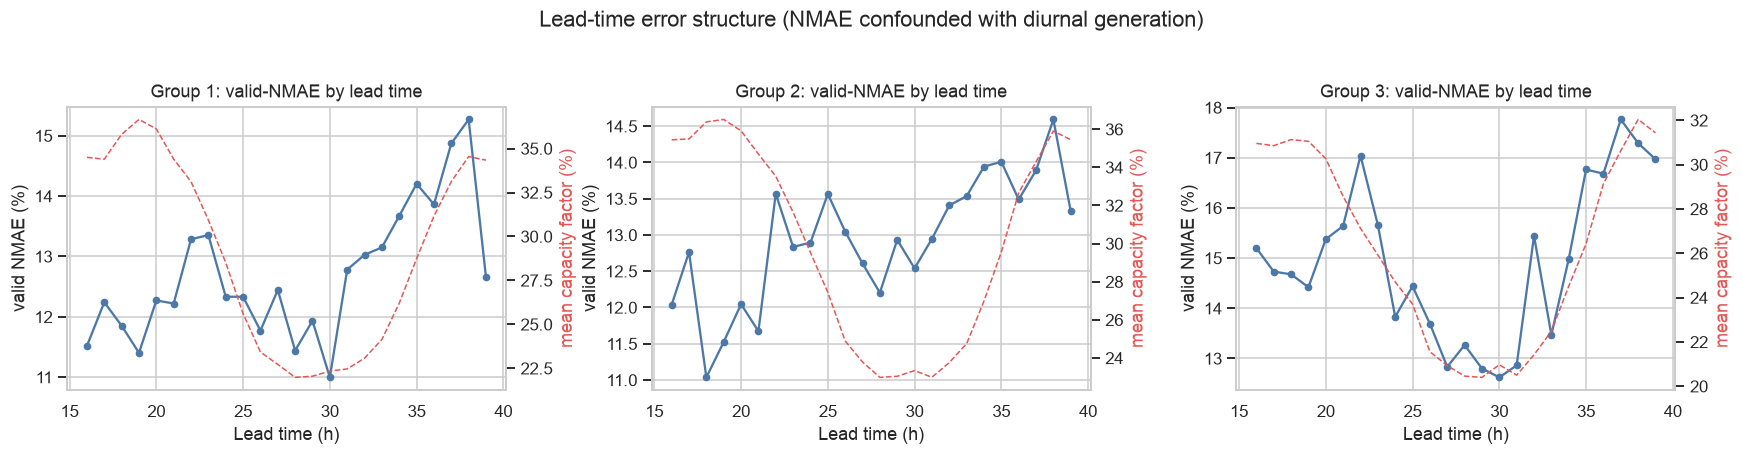

group1: NMAE~lead 기울기=+0.0993 %p/h, corr=+0.640, 범위 11.00~15.27%
group2: NMAE~lead 기울기=+0.0930 %p/h, corr=+0.758, 범위 11.04~14.59%
group3: NMAE~lead 기울기=+0.0628 %p/h, corr=+0.282, 범위 12.62~17.76%


In [3]:
def lead_from_hour(h):
    # h in 0..23 (valid time hour). 01:00->16h ... 23:00->38h, 00:00->39h
    return np.where(h == 0, 39, h + 15)

_hours = np.arange(24)
_leads = lead_from_hour(_hours)
assert _leads.tolist() == [39] + list(range(16, 39))
assert set(_leads) == set(range(16, 40))
print("lead mapping verified: 01:00->16h ... 23:00->38h, 00:00->39h")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
lead_tables = {}
for ax, g in zip(axes, (1, 2, 3)):
    va, tgt = HOLD[g]
    d = va.copy()
    d["lead"] = lead_from_hour(d["kst_dtm"].dt.hour.to_numpy())
    rows = []
    for lead, grp in d.groupby("lead"):
        nm, n = nmae_valid(grp[tgt], grp["pred"], CAP[g], mask_by_true=True)
        rows.append(dict(lead=lead, nmae=nm, n_valid=n,
                         mean_cf=100 * grp[tgt].mean() / CAP[g]))
    t = pd.DataFrame(rows).sort_values("lead")
    lead_tables[g] = t
    ax.plot(t.lead, t.nmae, marker="o", ms=4, color="#4C78A8", label="valid NMAE (%)")
    ax.set_title(f"Group {g}: valid-NMAE by lead time")
    ax.set_xlabel("Lead time (h)"); ax.set_ylabel("valid NMAE (%)")
    ax2 = ax.twinx()
    ax2.plot(t.lead, t.mean_cf, color="#E45756", lw=1, ls="--", label="mean CF (%)")
    ax2.set_ylabel("mean capacity factor (%)", color="#E45756")
    ax2.grid(False)
plt.suptitle("Lead-time error structure (NMAE confounded with diurnal generation)", y=1.03)
plt.tight_layout(); plt.show()

# 리드타임 오차의 실제 추세: 선형회귀 기울기 + 상관
for g in (1, 2, 3):
    t = lead_tables[g]
    slope = np.polyfit(t.lead, t.nmae, 1)[0]
    r = np.corrcoef(t.lead, t.nmae)[0, 1]
    print(f"group{g}: NMAE~lead 기울기={slope:+.4f} %p/h, corr={r:+.3f}, "
          f"범위 {t.nmae.min():.2f}~{t.nmae.max():.2f}%")

**해석 가이드** — 기울기가 뚜렷이 양(+)이고 mean-CF 곡선과 반대로 움직이면 "리드타임이 길수록 어려워진다"는 실제 신호입니다. 반대로 NMAE 곡선이 mean-CF 곡선을 거울처럼 뒤집은 모양이면, 오차는 리드타임이 아니라 **그 시각의 발전량 수준(일중 패턴)** 을 따라간다는 뜻이고, 이 경우 리드타임 feature보다 **시각/일중 변수(이미 hour_sin/cos 존재)** 로 충분합니다. 결론은 출력된 기울기·상관값으로 판정합니다.

## 2. 연도 간 분포 이동 (2022 / 2023 / 2024 / 2025-test)

**질문**: 학습 연도별 풍속·발전량 분포가 서로, 그리고 2025 테스트와 얼마나 다른가?
- 크게 다르면 → 2024 holdout이 2025를 대표하지 못할 수 있고, RevIN/도메인보정 가치가 커집니다.
- 비슷하면 → 단순 시간분할 검증이 타당하고, 분포보정 이득은 작습니다.

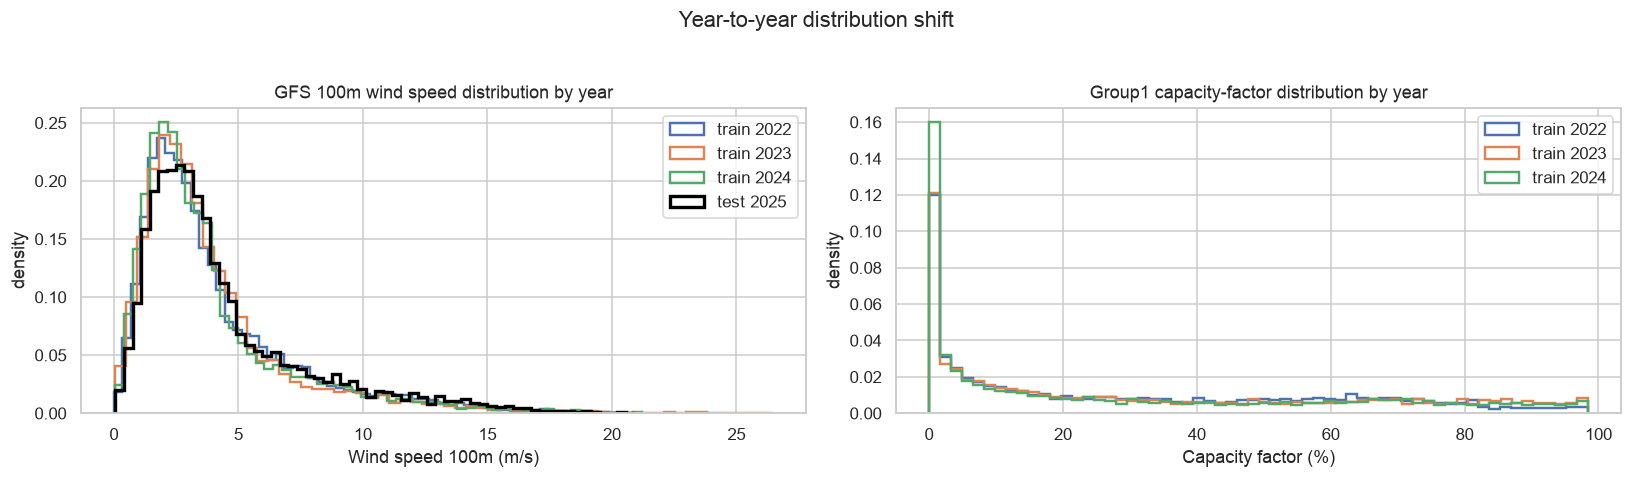

In [4]:
HUB = "kpx_group_1_gfs_wind_speed_100m_mean"   # 허브고도 근접 풍속 대표

def year_frames(g):
    df, tgt = TR[g]
    df = df.copy(); df["year"] = df.kst_dtm.dt.year
    df = df[df["year"].isin(TRAIN_YEARS)].copy()
    return df, tgt

df1, tgt1 = year_frames(1)
test1 = TE[1]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
# (a) 풍속 분포: train 연도별 + 2025 test
ax = axes[0]
for y in TRAIN_YEARS:
    s = df1.loc[df1.year == y, HUB].dropna()
    if len(s) == 0:
        continue
    ax.hist(s, bins=60, density=True, histtype="step", lw=1.6, label=f"train {y}")
ax.hist(test1[HUB].dropna(), bins=60, density=True, histtype="step", lw=2.2,
        color="black", label="test 2025")
ax.set_title("GFS 100m wind speed distribution by year")
ax.set_xlabel("Wind speed 100m (m/s)"); ax.set_ylabel("density"); ax.legend()
# (b) 발전량(CF) 분포: train 연도별 (2025 타깃 없음)
ax = axes[1]
for y in TRAIN_YEARS:
    s = 100 * df1.loc[df1.year == y, tgt1] / CAP[1]
    if len(s) == 0:
        continue
    ax.hist(s.dropna(), bins=60, density=True, histtype="step", lw=1.6, label=f"train {y}")
ax.set_title("Group1 capacity-factor distribution by year")
ax.set_xlabel("Capacity factor (%)"); ax.set_ylabel("density"); ax.legend()
plt.suptitle("Year-to-year distribution shift", y=1.03)
plt.tight_layout(); plt.show()

In [5]:
# 정량화: 연도별 풍속 평균/표준편차 + KS 거리(2025 test 대비, 그룹평균)
print("=== 허브풍속(GFS 100m) 연도별 요약 (group1; train 2022~2024 only) ===")
train_summ = df1.groupby("year")[HUB].agg(["mean", "std", "count"])
assert set(train_summ.index).issubset(set(TRAIN_YEARS))
summ = train_summ.round(3)
summ.loc["test2025"] = [test1[HUB].mean(), test1[HUB].std(), test1[HUB].count()]
print(summ.round(3).to_string())

print("\n=== KS 거리: 각 학습연도 풍속 vs 2025 test 풍속 (사용 가능 그룹 평균) ===")
for y in TRAIN_YEARS:
    ks_list = []
    used_groups = []
    for g in (1, 2, 3):
        dfg, _ = year_frames(g)
        col = f"kpx_group_{g}_gfs_wind_speed_100m_mean"
        a = dfg.loc[dfg.year == y, col].dropna()
        b = TE[g][col].dropna()
        if len(a) == 0 or len(b) == 0:
            continue
        ks_list.append(ks_2samp(a, b).statistic)
        used_groups.append(g)
    if ks_list:
        print(f"  train {y} vs test2025 : KS={np.mean(ks_list):.4f} (groups={used_groups})")
    else:
        print(f"  train {y} vs test2025 : KS=NA (no non-empty groups)")

print("\n=== 참고: 학습연도끼리 KS (group1 풍속) ===")
for a_y, b_y in [(2022, 2023), (2023, 2024), (2022, 2024)]:
    a = df1.loc[df1.year == a_y, HUB].dropna(); b = df1.loc[df1.year == b_y, HUB].dropna()
    if len(a) == 0 or len(b) == 0:
        print(f"  {a_y} vs {b_y}: KS=NA")
    else:
        print(f"  {a_y} vs {b_y}: KS={ks_2samp(a, b).statistic:.4f}")

=== 허브풍속(GFS 100m) 연도별 요약 (group1; train 2022~2024 only) ===
           mean    std   count
year                          
2022      4.123  3.241  8664.0
2023      3.900  3.134  8757.0
2024      3.891  3.125  8778.0
test2025  4.384  3.362  8760.0

=== KS 거리: 각 학습연도 풍속 vs 2025 test 풍속 (사용 가능 그룹 평균) ===


  train 2022 vs test2025 : KS=0.0533 (groups=[1, 2])


  train 2023 vs test2025 : KS=0.0637 (groups=[1, 2, 3])


  train 2024 vs test2025 : KS=0.0840 (groups=[1, 2, 3])

=== 참고: 학습연도끼리 KS (group1 풍속) ===
  2022 vs 2023: KS=0.0519
  2023 vs 2024: KS=0.0255
  2022 vs 2024: KS=0.0446


**해석 가이드** — 2025 test 풍속 곡선(검은 선)이 학습 연도 곡선들의 범위 안에 있고 KS가 학습연도끼리의 KS와 비슷하면, 2025는 학습분포 내 보간에 가깝고 **2024 holdout이 대표성 있음**입니다. 반대로 test KS가 눈에 띄게 크면 **공변량 이동**이 있으니 RevIN/입력 표준화·연도 robust 검증의 가치가 올라갑니다. 발전량 CF의 연도 편차가 크면 타깃 레벨 이동이므로 **연도별 bias 보정**도 후보입니다.

## 3. "바람 있는데 발전 0" — 파워커브 프록시 하한

**질문**: NWP는 발전할 만한 바람을 예보하는데 실제 발전이 0에 가까운 시간이 얼마나 되고, 공식 유효구간에서는 풍속 파워커브만으로 어느 정도 오차가 남는가?

`CONSTRAINTS`/리서치 문서는 이 신호(고장·출력제한)를 SCADA에만 있고 2025에 예측 불가한 "오차 하한 ~6~9%"로 언급합니다. 원본 SCADA가 repo에 없으므로 **NWP 허브풍속으로 기대발전량(경험적 파워커브)을 만들고, 실제 발전이 그보다 크게 낮은(특히 ~0인) 시간**을 별도 진단값으로 정량화합니다. 단, 대회 NMAE는 **실측 ≥ 설비용량 10%**만 채점하므로, `powercurve_floor_nmae_pct`는 실측 유효구간에서만 계산합니다. 이 파워커브는 학습구간에서만 적합하며 테스트 입력을 쓰지 않습니다.

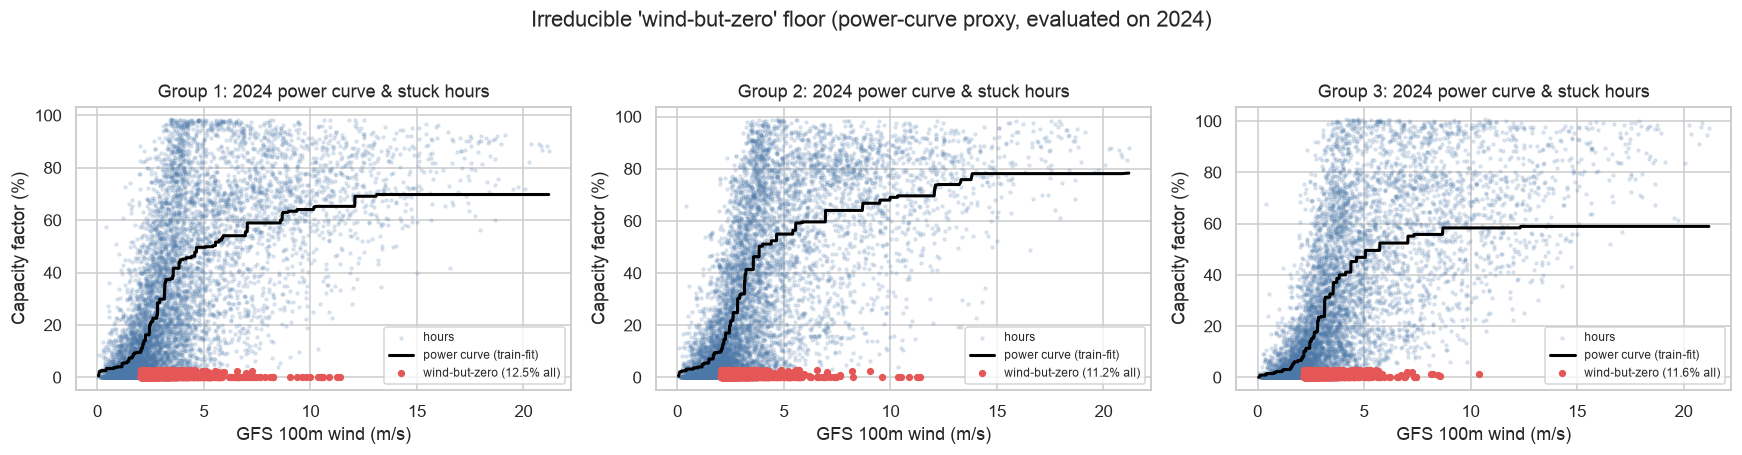

       valid_hours  windy_hours  stuck_hours  stuck_pct_all_hours  stuck_pct_of_windy  stuck_scored_hours  powercurve_floor_nmae_pct
group                                                                                                                               
1             4990         6195         1099                12.52               17.74                   0                      18.50
2             4977         6129          985                11.22               16.07                   0                      18.11
3             4567         5878         1019                11.61               17.34                   0                      19.40

해석: powercurve_floor_nmae_pct = 대회 유효구간(실측 CF>=10%)에서 풍속 파워커브가 남기는 NMAE.
stuck_*는 전체 2024 시간 진단값이며, 실측 CF<3%라 공식 유효구간에는 보통 포함되지 않습니다.


In [6]:
def empirical_power_curve(df, tgt, cap, wind_col):
    """학습구간 풍속->CF 단조증가 파워커브(isotonic). 반환: 예측함수."""
    d = pd.DataFrame({"ws": df[wind_col].to_numpy(),
                      "cf": (df[tgt] / cap).to_numpy()}).dropna()
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip", increasing=True)
    iso.fit(d.ws, d.cf)
    return iso

rows = []
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, g in zip(axes, (1, 2, 3)):
    df, tgt = TR[g]; cap = CAP[g]
    wind_col = f"kpx_group_{g}_gfs_wind_speed_100m_mean"
    # 파워커브는 학습(2022~2023)에서만 적합 -> 2024에서 평가(누설 방지)
    tr = df[df.kst_dtm < VALID_START]
    va = df[(df.kst_dtm >= VALID_START) & (df.kst_dtm < VALID_END)].copy()
    iso = empirical_power_curve(tr, tgt, cap, wind_col)
    va["cf"] = va[tgt] / cap
    va["exp_cf"] = iso.predict(va[wind_col].to_numpy())   # 파워커브 기대 CF
    # "바람 있는데 발전 0": 기대 CF는 유효(>=10%)인데 실측이 사실상 0(<3%). 공식 NMAE와 별도 진단값.
    valid = va["cf"] >= VALID_CF                          # 대회 유효구간은 반드시 실측 기준
    windy = va["exp_cf"] >= VALID_CF
    dead = va["cf"] < 0.03
    stuck = windy & dead
    stuck_pct_all = 100 * stuck.mean()
    stuck_pct_windy = 100 * stuck.sum() / windy.sum() if windy.sum() else np.nan
    # 대회 지표 기준 하한: 실측 유효구간에서 풍속 파워커브가 남기는 NMAE(CF MAE).
    floor_nmae = (va.loc[valid, "exp_cf"] - va.loc[valid, "cf"]).abs().mean() * 100
    rows.append(dict(group=g,
                     valid_hours=int(valid.sum()),
                     windy_hours=int(windy.sum()),
                     stuck_hours=int(stuck.sum()),
                     stuck_pct_all_hours=round(stuck_pct_all, 2),
                     stuck_pct_of_windy=round(stuck_pct_windy, 2),
                     stuck_scored_hours=int((stuck & valid).sum()),
                     powercurve_floor_nmae_pct=round(floor_nmae, 2)))
    # 시각화: 파워커브 + stuck 점
    d = va.dropna(subset=[wind_col])
    ax.scatter(d[wind_col], 100 * d["cf"], s=4, alpha=0.15, color="#4C78A8", label="hours")
    order = np.argsort(d[wind_col].to_numpy())
    ax.plot(d[wind_col].to_numpy()[order], 100 * d["exp_cf"].to_numpy()[order],
            color="black", lw=2, label="power curve (train-fit)")
    sd = d[stuck.reindex(d.index, fill_value=False)]
    ax.scatter(sd[wind_col], 100 * sd["cf"], s=14, color="#E45756",
               label=f"wind-but-zero ({stuck_pct_all:.1f}% all)")
    ax.set_title(f"Group {g}: 2024 power curve & stuck hours")
    ax.set_xlabel("GFS 100m wind (m/s)"); ax.set_ylabel("Capacity factor (%)")
    ax.legend(fontsize=8)
plt.suptitle("Irreducible 'wind-but-zero' floor (power-curve proxy, evaluated on 2024)", y=1.03)
plt.tight_layout(); plt.show()

floor_df = pd.DataFrame(rows).set_index("group")
print(floor_df.to_string())
print("\n해석: powercurve_floor_nmae_pct = 대회 유효구간(실측 CF>=10%)에서 풍속 파워커브가 남기는 NMAE.")
print("stuck_*는 전체 2024 시간 진단값이며, 실측 CF<3%라 공식 유효구간에는 보통 포함되지 않습니다.")

**해석 가이드** — `stuck_pct_all_hours`/`stuck_pct_of_windy`는 바람이 충분하다고 기대되는데 실측 발전이 0에 가까운 시간의 비율입니다. 이 시간들은 NWP 풍속으로는 예측 불가(고장·정지·출력제한)한 진단 신호이지만, 실측 CF가 10% 미만이면 대회 유효구간 NMAE에는 들어가지 않습니다. 따라서 `powercurve_floor_nmae_pct`는 별도로 **실측 CF ≥ 10%인 공식 유효구간에서만** 계산한 풍속-파워커브 프록시 하한입니다. 모델링 노력이 이 하한 근처에 도달하면 그 이상은 feature보다 라벨 정제나 정지구간 처리 가설을 따로 검증해야 합니다.

## 4. 풍향 효과의 교란 — 방향인가, 풍속인가?

**질문**: `EDA_MAIN` 4-4에서 SW 방향 이용률 48%가 나왔지만, SW가 주풍향이라 **풍속 자체가 세서** 생긴 착시일 수 있습니다. 풍속을 통제(같은 풍속 구간 안에서 비교)하면 방향 효과가 남는지 봅니다.

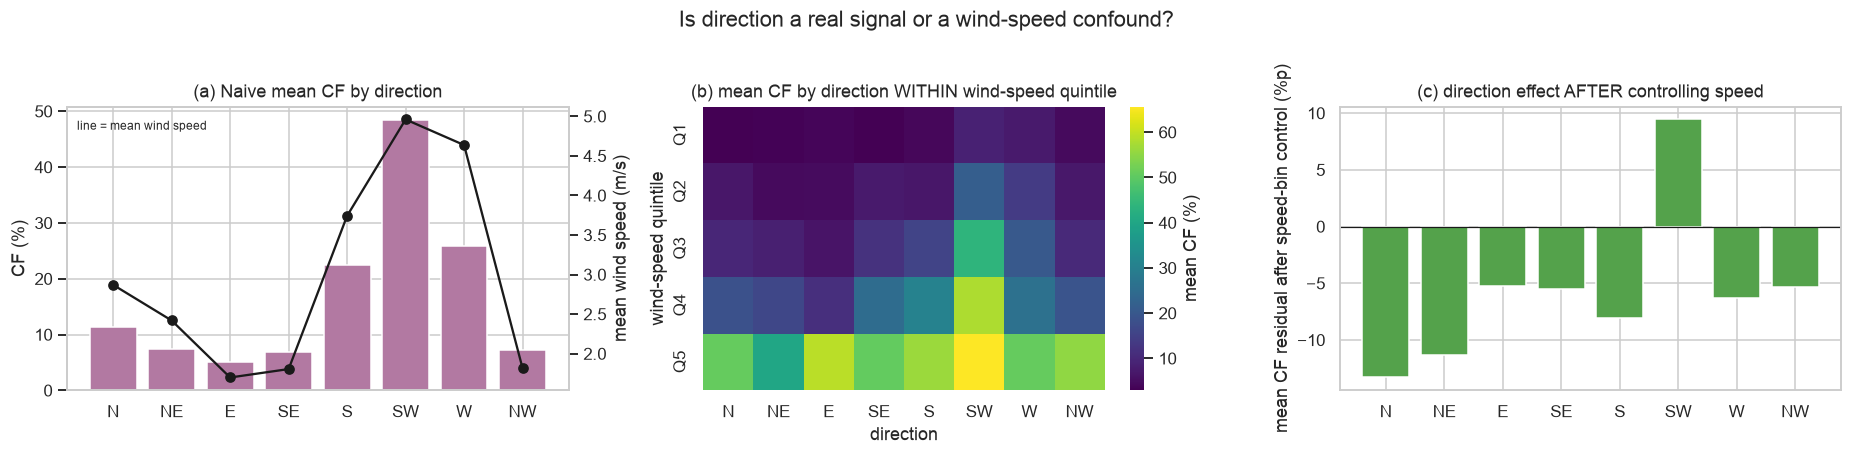

=== 방향별 naive 평균 (교란 포함) ===
        mean_cf  mean_spd      n
sector                          
N          11.3       2.9   2356
NE          7.4       2.4   2972
E           5.0       1.7   1315
SE          6.9       1.8   1084
S          22.5       3.7   2083
SW         48.4       5.0  12524
W          25.8       4.6   3178
NW          7.2       1.8    687

=== 풍속 통제 후 방향별 잔차 (관측치 단위) ===
sector
N    -13.3
NE   -11.3
E     -5.2
SE    -5.5
S     -8.0
SW     9.4
W     -6.3
NW    -5.3

naive 방향간 CF 격차 = 43.4%p
풍속 통제 후 잔여 방향 격차 = 22.8%p
교란으로 설명되는 비율 ≈ 48%


In [7]:
g = 1
df, tgt = year_frames(g); cap = CAP[g]
order = ["N","NE","E","SE","S","SW","W","NW"]
u = df[f"kpx_group_{g}_gfs_heightAboveGround_100_100u_mean"].to_numpy()
v = df[f"kpx_group_{g}_gfs_heightAboveGround_100_100v_mean"].to_numpy()
spd = df[f"kpx_group_{g}_gfs_wind_speed_100m_mean"].to_numpy()
wd = (np.degrees(np.arctan2(-u, -v)) % 360)   # 기상관례: 불어오는 방향
sector = pd.cut(wd, bins=np.arange(0, 361, 45), labels=order,
                include_lowest=True, right=False)
d = pd.DataFrame({"sector": sector, "spd": spd, "cf": 100 * df[tgt].to_numpy() / cap}).dropna()

# (a) naive: 방향별 평균 CF + 방향별 평균 풍속 (교란 노출)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
by_dir = d.groupby("sector", observed=True).agg(mean_cf=("cf","mean"),
                                                mean_spd=("spd","mean"),
                                                n=("cf","size")).reindex(order)
ax = axes[0]
ax.bar(order, by_dir.mean_cf, color="#B279A2")
ax.set_title("(a) Naive mean CF by direction"); ax.set_ylabel("CF (%)")
ax2 = axes[0].twinx(); ax2.plot(order, by_dir.mean_spd, "ko-", lw=1.5); ax2.grid(False)
ax2.set_ylabel("mean wind speed (m/s)")
ax.text(0.02, 0.95, "line = mean wind speed", transform=ax.transAxes, fontsize=8, va="top")

# (b) 풍속 통제: 풍속 5분위 안에서 방향별 평균 CF
q = pd.qcut(d.spd, 5, labels=False, duplicates="drop")
d["spd_q"] = pd.Categorical("Q" + (q.astype(int) + 1).astype(str),
                            categories=[f"Q{i}" for i in range(1, int(q.max()) + 2)],
                            ordered=True)
piv = d.pivot_table(index="spd_q", columns="sector", values="cf",
                    aggfunc="mean", observed=True).reindex(columns=order)
ax = axes[1]
sns.heatmap(piv, cmap="viridis", ax=ax, cbar_kws={"label": "mean CF (%)"})
ax.set_title("(b) mean CF by direction WITHIN wind-speed quintile")
ax.set_xlabel("direction"); ax.set_ylabel("wind-speed quintile")

# (c) 통제 후 방향의 잔여 효과: 관측치별로 같은 풍속분위 평균을 뺀 뒤 방향별 평균
speed_bin_mean = d.groupby("spd_q", observed=True)["cf"].transform("mean")
d["cf_resid_speed"] = d["cf"] - speed_bin_mean
resid_by_dir = d.groupby("sector", observed=True)["cf_resid_speed"].mean().reindex(order)
ax = axes[2]
ax.bar(order, resid_by_dir, color="#54A24B")
ax.axhline(0, color="k", lw=0.8)
ax.set_title("(c) direction effect AFTER controlling speed")
ax.set_ylabel("mean CF residual after speed-bin control (%p)")
plt.suptitle("Is direction a real signal or a wind-speed confound?", y=1.03)
plt.tight_layout(); plt.show()

print("=== 방향별 naive 평균 (교란 포함) ===")
print(by_dir.round(1).to_string())
print("\n=== 풍속 통제 후 방향별 잔차 (관측치 단위) ===")
print(resid_by_dir.round(1).to_string())
naive_spread = by_dir.mean_cf.max() - by_dir.mean_cf.min()
resid_spread = resid_by_dir.max() - resid_by_dir.min()
explained = 100 * (1 - resid_spread / naive_spread) if naive_spread else np.nan
print(f"\nnaive 방향간 CF 격차 = {naive_spread:.1f}%p")
print(f"풍속 통제 후 잔여 방향 격차 = {resid_spread:.1f}%p")
print(f"교란으로 설명되는 비율 ≈ {explained:.0f}%")

**해석 가이드** — (a)에서 CF 막대와 풍속 선이 같이 높으면 교란 의심. (b) 히트맵에서 **같은 풍속분위 행 안에서도** 방향별로 색이 다르면 방향은 독립적 신호(지형 효과 등)입니다. (c)는 관측치마다 같은 풍속분위 평균 CF를 뺀 뒤 방향별 잔차를 평균한 값입니다. 잔여 격차가 naive 격차보다 크게 작아지면(=교란 설명비율이 높으면) 방향의 순수 기여는 작다는 뜻입니다. 순수 기여가 작더라도 풍향 sin/cos는 트리모델에 저비용이라 유지해도 무방하지만, **"방향이 발전량을 크게 좌우한다"는 서술은 완화**해야 합니다.

## 5. 종합 판단 (출력값으로 채워 해석)

| 질문 | 판정 방법 | 이 노트북의 산출물 |
|---|---|---|
| 1. 리드타임 오차 | NMAE~lead 기울기·상관, mean-CF와의 결합 | 기울기 부호가 유의하고 CF와 독립이면 리드 feature 유효; 아니면 hour_sin/cos로 충분 |
| 2. 분포 이동 | test2025 vs 학습연도 KS | test KS ≈ 학습연도끼리 KS면 2024 holdout 대표성 OK / 크면 RevIN·연도 robust 검증 |
| 3. 무발전/파워커브 하한 | stuck 비율 + powercurve_floor_nmae_pct | stuck은 비채점 진단, 하한은 실측 유효구간 기준 풍속-파워커브 프록시 |
| 4. 풍향 교란 | 풍속 통제 후 잔여 격차 / naive 격차 | 교란 설명비율 높으면 방향은 보조신호로 격하 |

> 이 표의 빈칸은 위 셀 실행 후 출력된 수치로 채워, `baram2026_project_plan.md`의 feature/검증 결정에 반영합니다.